# Validation croisée — K-Fold Stratifié Répété
Même données que `analyse_SVM.ipynb`, mais évaluation par **RepeatedStratifiedKFold** (K=4, 10 répétitions)  
au lieu de Leave-One-Out. Objectif : obtenir un écart-type vraiment informatif sur la stabilité des modèles.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'], check=True)

CompletedProcess(args=['c:\\Users\\mariu\\OneDrive\\Documents\\dèv\\projet_SVM_fiabila\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'openpyxl', '-q'], returncode=0)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, NuSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, LeaveOneOut

%matplotlib inline

## 1. Chargement des données

In [3]:
FILE_PATH = r'C:\Users\mariu\onedrive\documents\dèv\projet_SVM_fiabila\bilan SVM.xlsx'

raw = pd.read_excel(FILE_PATH, engine='openpyxl', header=None)

DATA_START = 4
DATA_END   = 24

def extract_group(col_duree, col_temp, col_pression, label_val):
    rows = []
    for i in range(DATA_START, DATA_END):
        lot   = raw.iat[i, col_duree - 1]
        duree = raw.iat[i, col_duree]
        temp  = raw.iat[i, col_temp]
        press = raw.iat[i, col_pression]
        if pd.isna(lot) or str(lot).strip() in ('', 'nan'):
            continue
        rows.append({'Lot': lot, 'Durée (min)': duree, 'Temp. (°C)': temp, 'Pression (bar)': press, 'label': label_val})
    return pd.DataFrame(rows)

bon     = extract_group(col_duree=2, col_temp=3, col_pression=4, label_val=1)
mauvais = extract_group(col_duree=7, col_temp=8, col_pression=9, label_val=0)

df = pd.concat([bon, mauvais], ignore_index=True)

for col in ['Durée (min)', 'Temp. (°C)', 'Pression (bar)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Temp. (°C)'] = df.groupby('label')['Temp. (°C)'].transform(lambda g: g.fillna(g.mean()))

FEATURE_COLS = ['Durée (min)', 'Temp. (°C)', 'Pression (bar)']
X_raw = df[FEATURE_COLS].values
y     = df['label'].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Total : {len(df)} fabrications  (BON={( y==1).sum()}  MAUVAIS={(y==0).sum()})')

Total : 28 fabrications  (BON=20  MAUVAIS=8)


## 2. Définition des modèles
Paramètres optimisés issus de la section 8b de `analyse_SVM.ipynb`.

In [4]:
models = {
    'SVM Linéaire':           SVC(kernel='linear', C=1,     random_state=42),
    'SVM Linéaire (bal.)':    SVC(kernel='linear', C=0.001, class_weight='balanced', random_state=42),
    'SVM RBF':                SVC(kernel='rbf',    C=10,    gamma=0.1, random_state=42),
    'SVM RBF (bal.)':         SVC(kernel='rbf',    C=1,     gamma=1.0, class_weight='balanced', random_state=42),
    'SVM Poly deg=2 (bal.)':  SVC(kernel='poly',   degree=2, C=0.001,  class_weight='balanced', random_state=42),
    'SVM Poly deg=3 (bal.)':  SVC(kernel='poly',   degree=3, C=0.001,  class_weight='balanced', random_state=42),
    'NuSVC RBF (bal.)':       NuSVC(kernel='rbf',  nu=0.2,  class_weight='balanced'),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
}

## 3. Évaluation — K-Fold Stratifié Répété (K=4, 10 répétitions)

**Pourquoi K=4 ?**  
Avec seulement 8 MAUVAIS, K=4 garantit exactement **2 MAUVAIS par fold test** — le minimum pour un score stable.  
K=5 donnerait 1 ou 2 MAUVAIS par fold (trop instable).

**Pourquoi 10 répétitions ?**  
Chaque répétition utilise un découpage aléatoire différent → 40 scores par modèle.  
L'écart-type de ces 40 scores mesure vraiment la **stabilité** du modèle, pas juste `√(p×(1-p))`.

In [5]:
import warnings
warnings.filterwarnings('ignore')

cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=10, random_state=42)

kfold_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    kfold_results[name] = {
        'Accuracy K-Fold': scores.mean(),
        'Écart-type':      scores.std(),
        'N scores':        len(scores),
    }
    print(f'{name:25s}: {scores.mean():.1%} ± {scores.std():.1%}')

SVM Linéaire             : 64.3% ± 9.6%
SVM Linéaire (bal.)      : 28.6% ± 0.0%
SVM RBF                  : 74.6% ± 15.1%
SVM RBF (bal.)           : 81.8% ± 13.5%
SVM Poly deg=2 (bal.)    : 28.6% ± 0.0%
SVM Poly deg=3 (bal.)    : 28.6% ± 0.0%
NuSVC RBF (bal.)         : 74.3% ± 16.4%
Random Forest            : 81.4% ± 12.9%


## 4. Tableau comparatif K-Fold

In [6]:
df_kfold = pd.DataFrame(kfold_results).T.reset_index()
df_kfold.columns = ['Modèle', 'Accuracy K-Fold', 'Écart-type', 'N scores']
df_kfold = df_kfold.sort_values('Accuracy K-Fold', ascending=False).reset_index(drop=True)

df_kfold.style \
    .highlight_max(subset=['Accuracy K-Fold'], color='#c8f7c5') \
    .highlight_min(subset=['Accuracy K-Fold'], color='#ffd6d6') \
    .format({'Accuracy K-Fold': '{:.1%}', 'Écart-type': '{:.1%}', 'N scores': '{:.0f}'})

,Modèle,Accuracy K-Fold,Écart-type,N scores
0,SVM RBF (bal.),81.8%,13.5%,40
1,Random Forest,81.4%,12.9%,40
2,SVM RBF,74.6%,15.1%,40
3,NuSVC RBF (bal.),74.3%,16.4%,40
4,SVM Linéaire,64.3%,9.6%,40
5,SVM Linéaire (bal.),28.6%,0.0%,40
6,SVM Poly deg=3 (bal.),28.6%,0.0%,40
7,SVM Poly deg=2 (bal.),28.6%,0.0%,40


## 5. LOOCV sur les mêmes modèles (pour comparaison directe)

In [7]:
loo = LeaveOneOut()
loocv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy', n_jobs=-1)
    loocv_results[name] = scores.mean()

print('LOOCV calculé.')

LOOCV calculé.


## 6. Comparaison LOOCV vs K-Fold Stratifié Répété

In [8]:
df_compare = df_kfold[['Modèle', 'Accuracy K-Fold', 'Écart-type']].copy()
df_compare['Accuracy LOOCV'] = df_compare['Modèle'].map(loocv_results)
df_compare['Δ (K-Fold − LOOCV)'] = df_compare['Accuracy K-Fold'] - df_compare['Accuracy LOOCV']
df_compare = df_compare.sort_values('Accuracy K-Fold', ascending=False).reset_index(drop=True)

df_compare.style \
    .highlight_max(subset=['Accuracy K-Fold'], color='#c8f7c5') \
    .highlight_max(subset=['Accuracy LOOCV'],  color='#d6eaff') \
    .format({
        'Accuracy K-Fold':    '{:.1%}',
        'Écart-type':         '{:.1%}',
        'Accuracy LOOCV':     '{:.1%}',
        'Δ (K-Fold − LOOCV)': '{:+.1%}',
    })

,Modèle,Accuracy K-Fold,Écart-type,Accuracy LOOCV,Δ (K-Fold − LOOCV)
0,SVM RBF (bal.),81.8%,13.5%,82.1%,-0.4%
1,Random Forest,81.4%,12.9%,85.7%,-4.3%
2,SVM RBF,74.6%,15.1%,82.1%,-7.5%
3,NuSVC RBF (bal.),74.3%,16.4%,78.6%,-4.3%
4,SVM Linéaire,64.3%,9.6%,60.7%,+3.6%
5,SVM Linéaire (bal.),28.6%,0.0%,71.4%,-42.9%
6,SVM Poly deg=3 (bal.),28.6%,0.0%,71.4%,-42.9%
7,SVM Poly deg=2 (bal.),28.6%,0.0%,71.4%,-42.9%


## 7. Graphique — Accuracy et intervalle de confiance

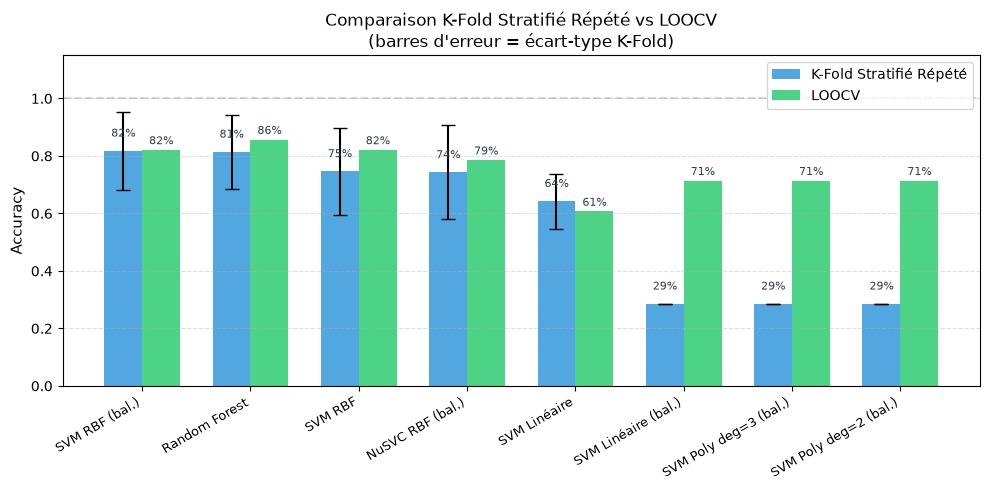

Figure sauvegardée : comparaison_kfold_loocv.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = df_compare['Modèle'].tolist()
acc_kf = df_compare['Accuracy K-Fold'].tolist()
std_kf = df_compare['Écart-type'].tolist()
acc_lo = df_compare['Accuracy LOOCV'].tolist()

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, acc_kf, width, yerr=std_kf, capsize=5,
               color='#3498db', alpha=0.85, label='K-Fold Stratifié Répété', error_kw=dict(linewidth=1.5))
bars2 = ax.bar(x + width/2, acc_lo, width,
               color='#2ecc71', alpha=0.85, label='LOOCV')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Comparaison K-Fold Stratifié Répété vs LOOCV\n(barres d\'erreur = écart-type K-Fold)', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.3)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar, acc in zip(bars1, acc_kf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{acc:.0%}', ha='center', va='bottom', fontsize=8, color='#2c3e50')
for bar, acc in zip(bars2, acc_lo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.0%}', ha='center', va='bottom', fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.savefig('comparaison_kfold_loocv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : comparaison_kfold_loocv.png')